In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

In [2]:
batch_size = 4
heads = 8
d_model = 256
d_k = d_model//heads
d_ff = 512
seq_len = 128
dropout = 0.1

# Model components

## Positional Encoding

In [3]:
from src.components.positional import PositionalEncoding

In [4]:
PE = PositionalEncoding(d_model=d_model)

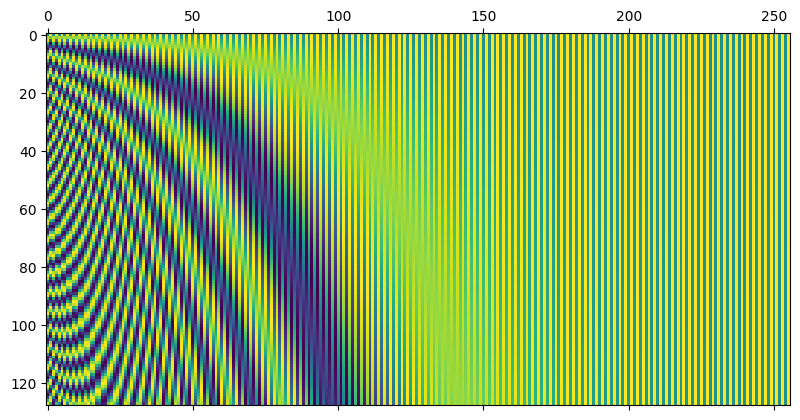

In [5]:
plt.matshow(PE.pe[:128,:]) # shows first 128 positions

## Scaled Dot Product Attention

In [6]:
from src.components.attention import ScaledDotProductAttention

In [7]:
SDPA = ScaledDotProductAttention(temperature=math.sqrt(d_model//heads))

Q = torch.randn((batch_size, heads, seq_len, d_k))
K = torch.randn((batch_size, heads, seq_len, d_k))
V = torch.randn((batch_size, heads, seq_len, d_k))

out, attn = SDPA(Q, K, V)

print(out.shape)

torch.Size([4, 8, 128, 32])


## MultiHeadAttention

In [8]:
from src.components.multihead import MultiHeadAttention

In [9]:
MHA = MultiHeadAttention(heads=heads, d_model=d_model)

Q = torch.randn((batch_size, seq_len, d_model))
K = torch.randn((batch_size, seq_len, d_model))
V = torch.randn((batch_size, seq_len, d_model))

out, attn = MHA(Q, K, V)

print(out.shape)

torch.Size([4, 128, 256])


## Feed Forward

In [10]:
from src.components.feedforward import FeedForward

In [11]:
FF = FeedForward(d_model=d_model, d_ff=d_ff, dropout=dropout)

x = torch.randn((batch_size, seq_len, d_model))
out = FF(x)
print(out.shape)

torch.Size([4, 128, 256])


## Encoder Layer

In [12]:
from src.components.encoder_layer import EncoderLayer

In [13]:
EL = EncoderLayer(d_model=d_model, heads=heads, d_ff=d_ff, dropout=dropout)

x = torch.randn((batch_size, seq_len, d_model))
out, attn = EL(x)
print(out.shape)

torch.Size([4, 128, 256])


## Transformer Encoder

In [14]:
from src.components.transformer_encoder import TransformerEncoder

In [15]:
vocab_size = 3000
TE = TransformerEncoder(vocab_size=vocab_size, num_layers=6, d_model=d_model, heads=heads, d_ff=d_ff, dropout=dropout)

x = torch.randint(vocab_size, (batch_size, seq_len))
out = TE(x)
print(out.shape)

torch.Size([4, 128, 256])
